<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec21_Unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

applying clustering to unsupervised data to find the financial status of the country

In [93]:
import pandas as pd
df = pd.read_csv('/content/_clustering data - Sheet1 (1).csv')
df.head(3)

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country
0,1548.814,55.68434,68.20993,15.04695,61.35474,38.55803,Country 1
1,1715.189,50.18790,60.97101,21.77817,62.98282,30.11714,Country 2
2,1602.763,56.17635,68.37945,17.70008,65.69965,33.59978,Country 3


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GDP per Capita         100 non-null    float64
 1   Life Expectancy        100 non-null    float64
 2   Literacy Rate          100 non-null    float64
 3   Unemployment Rate      100 non-null    float64
 4   Access to Clean Water  100 non-null    float64
 5   Poverty Rate           100 non-null    float64
 6   Country                100 non-null    object 
dtypes: float64(6), object(1)
memory usage: 5.6+ KB


In [95]:
#Feature Selection
df1 = df.drop('Country',axis=1)
df1

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate
0,1548.814,55.68434,68.20993,15.046950,61.35474,38.558030
1,1715.189,50.18790,60.97101,21.778170,62.98282,30.117140
2,1602.763,56.17635,68.37945,17.700080,65.69965,33.599780
3,1544.883,56.12096,60.96098,22.351940,65.90873,37.299910
4,1423.655,56.16934,69.76459,24.621890,65.74325,31.716300
...,...,...,...,...,...,...
95,3490.305,78.81720,89.06733,9.610557,86.33461,14.979620
96,3989.410,72.72437,90.52078,5.447473,94.80580,8.621891
97,3065.304,73.79057,87.71653,7.029712,93.71786,9.706489
98,3783.234,73.74296,89.55444,5.121566,90.02721,8.782452


In [96]:
df1.duplicated().sum()

np.int64(0)

No missing values and duplicates present

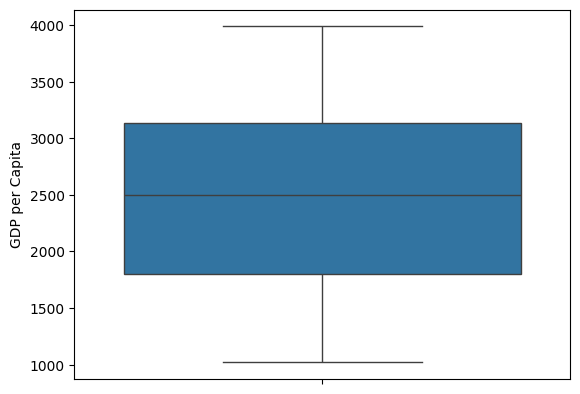

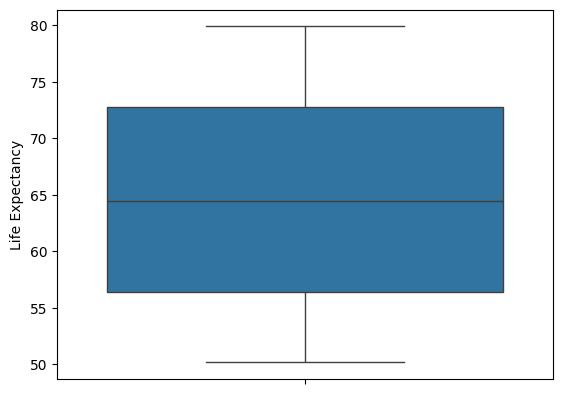

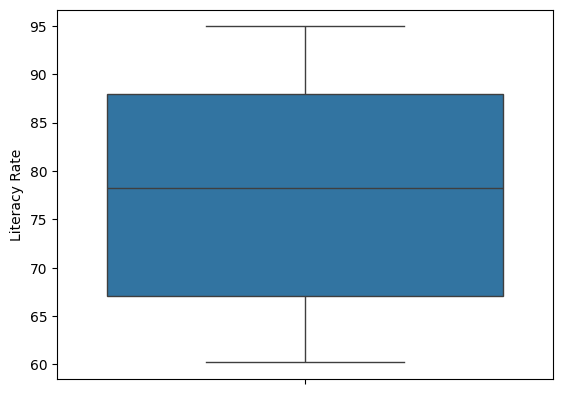

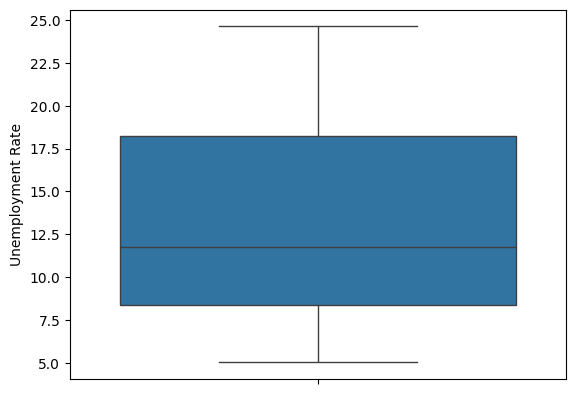

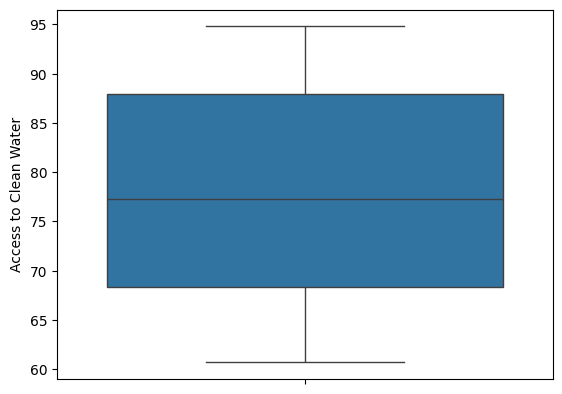

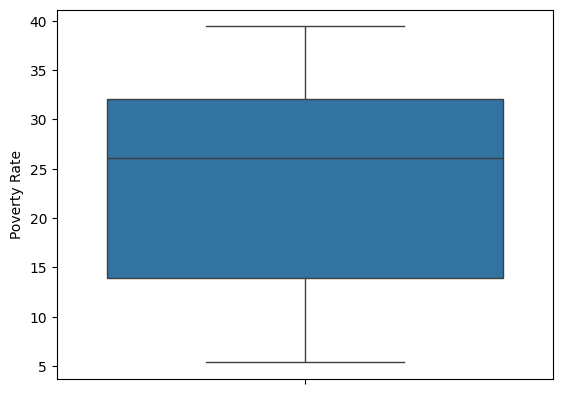

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
for i in df1:
  sns.boxplot(df1[i])
  plt.show()

<Axes: xlabel='GDP per Capita', ylabel='Literacy Rate'>

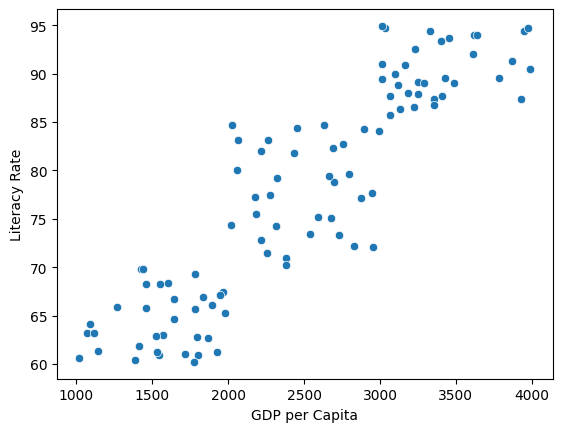

In [98]:
sns.scatterplot(x=df1['GDP per Capita'],y=df1['Literacy Rate'])

In [99]:
#As literacy rate increases GDP increases

In [100]:
df1.describe()

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2499.546730,64.747678,77.746925,13.287461,77.815276,23.413789
std,809.626188,9.149988,11.245180,5.869658,10.642503,10.504556
min,1020.218000,50.187900,60.201080,5.039421,60.691670,5.360338
25%,1797.300500,56.442397,67.103633,8.397232,68.378357,13.951227
50%,2495.138000,64.441300,78.232965,11.782680,77.274045,26.099410
75%,3139.029750,72.760908,87.957125,18.253077,87.927922,32.024588
max,3990.345000,79.920110,94.944010,24.621890,94.805800,39.443720


No outliers present

In [101]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled= scaler.fit_transform(df1)
features = pd.DataFrame(df_scaled,columns=df1.columns)
features.head(3)

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate
0,-1.180202,-0.995520,-0.852369,0.301270,-1.554471,1.448946
1,-0.973671,-1.599251,-1.499347,1.453830,-1.400721,0.641352
2,-1.113232,-0.941478,-0.837218,0.755555,-1.144154,0.974559


**Elbow method to find the optimum no.of clusters(n_clusters) for kmeans.**

In [102]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [103]:
#Apply the elbow method
inertia = []
k_values = range(1,11)
for k in k_values:
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(scaled_features)
  inertia.append(kmeans.inertia_)

In [104]:
k_values

range(1, 11)

In [105]:
inertia

[600.0,
 201.0816579347922,
 60.95739675119525,
 55.89515518373199,
 51.33375189119224,
 50.07749378388102,
 45.12409361795207,
 44.117163167756104,
 42.672749578809565,
 38.33612231731936]

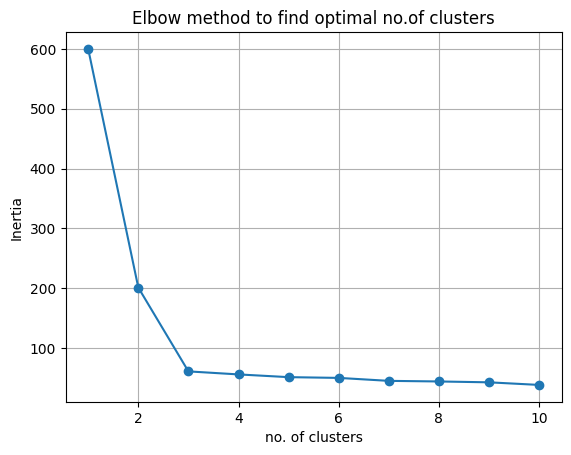

In [106]:
import matplotlib.pyplot as plt
plt.plot(k_values,inertia,marker='o')
plt.xlabel('no. of clusters')
plt.ylabel('Inertia')
plt.title('Elbow method to find optimal no.of clusters')
plt.grid(True)
plt.show()


optimal n_clusters = 3

In [107]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(features)

KMeans(n_clusters=3)

In [108]:
kmeans.predict(features)

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [109]:
#Adding cluster column
df['Cluster'] = kmeans.predict(features)

In [110]:
df.sample(3)

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country,Cluster
90,3974.256,79.50953,94.67795,5.151176,87.27760,12.39884,Country 91,1
49,2020.651,61.83280,74.39530,10.448020,77.78253,25.90984,Country 50,0
8,1963.663,54.37032,67.39264,20.722520,68.96547,30.18522,Country 9,2


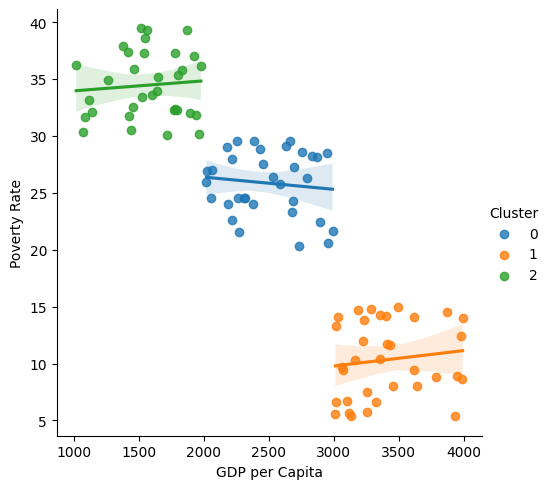

In [111]:
sns.lmplot(x='GDP per Capita',y='Poverty Rate',data=df,hue='Cluster')

* 0 is the richest cluster
* 2 is poor cluster

In [112]:
#obtaining country of cluster 2
df[df['Cluster']==2]['Country']

,Country
0,Country 1
1,Country 2
2,Country 3
3,Country 4
4,Country 5
5,Country 6
6,Country 7
7,Country 8
8,Country 9
9,Country 10


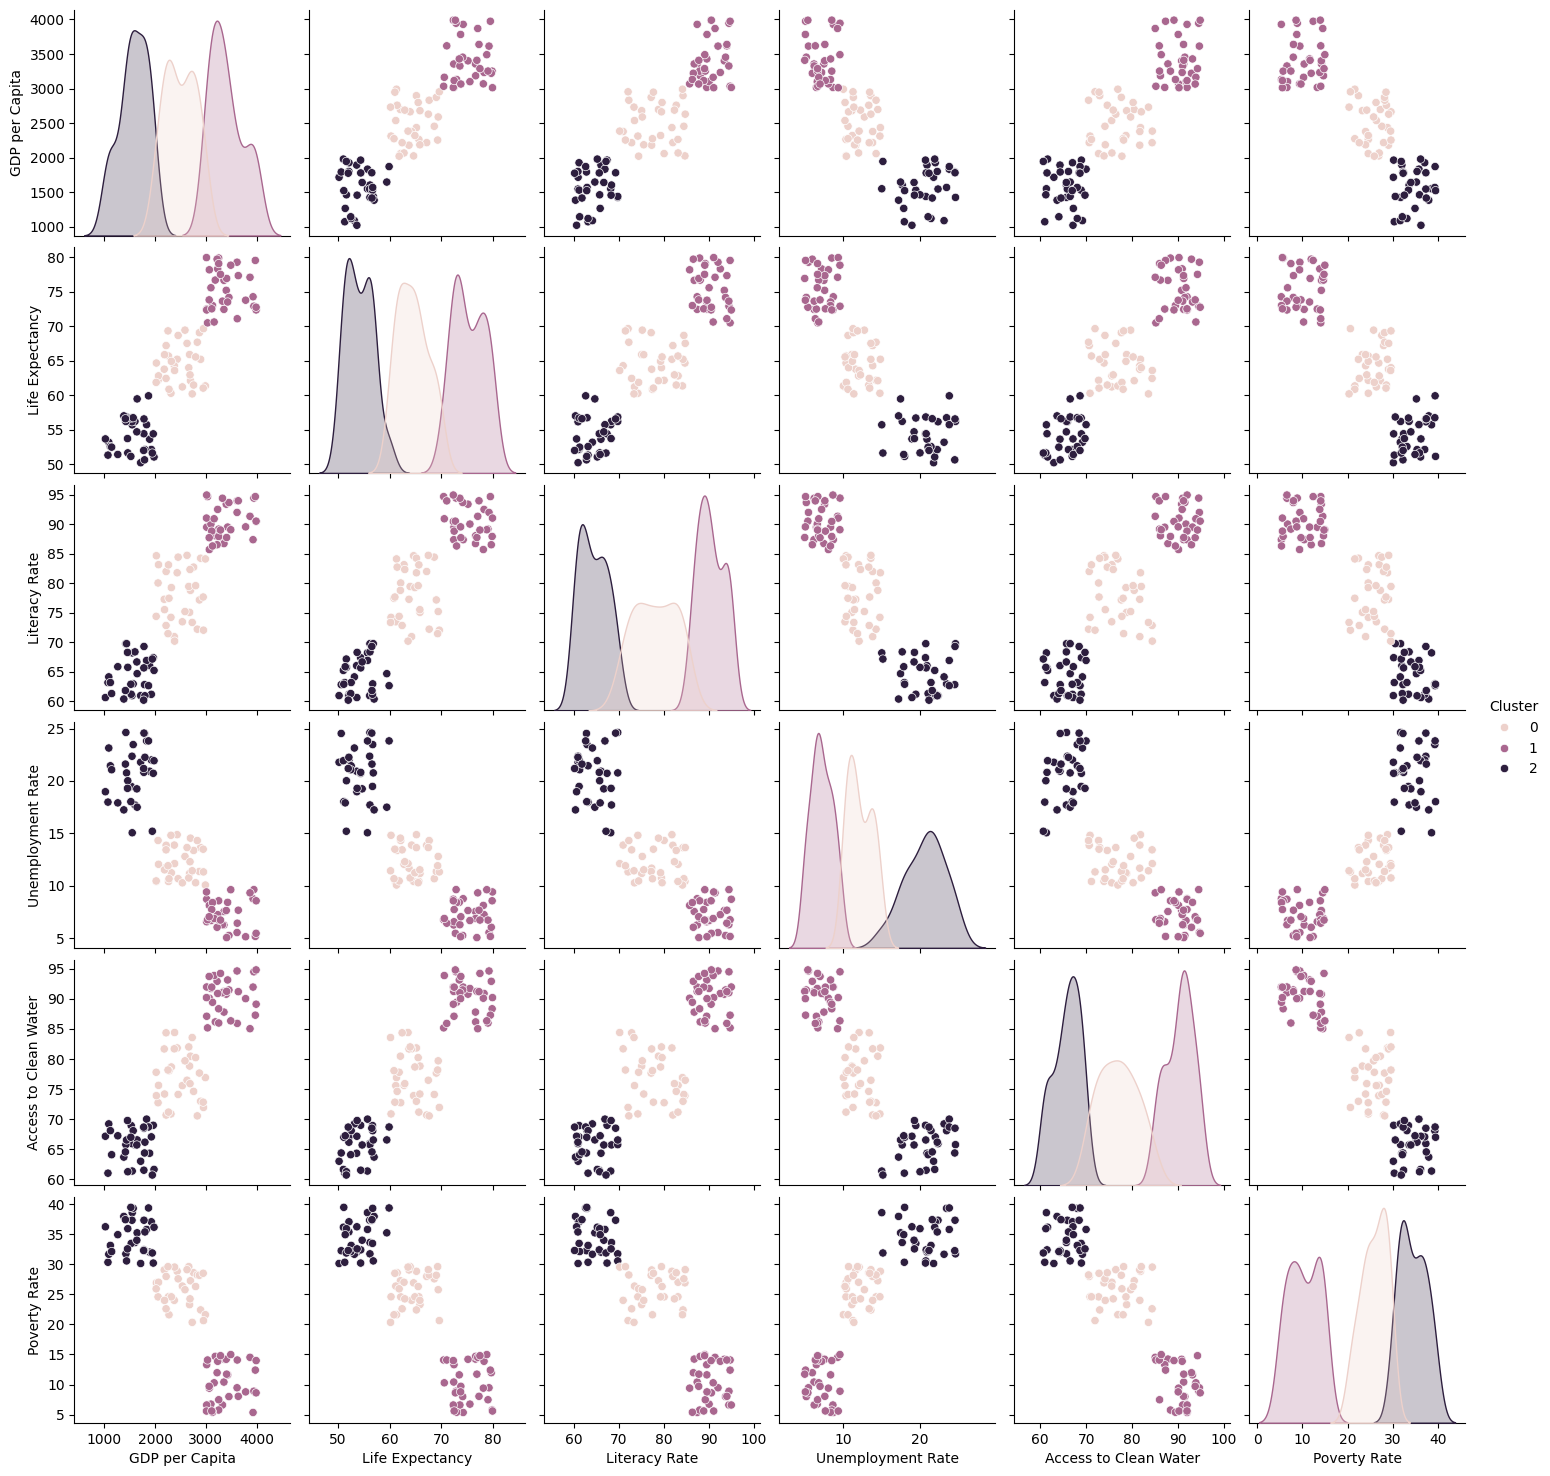

In [113]:
sns.pairplot(df,hue='Cluster')